# Learning curves — random forest on breast cancer

One small experiment a day. Seed fixed for reproducibility.

Is this model data-starved or capacity-limited? The learning curve says.

## Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.model_selection import learning_curve, validation_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                              GradientBoostingClassifier, GradientBoostingRegressor,
                              HistGradientBoostingClassifier, VotingClassifier,
                              IsolationForest)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, roc_auc_score, confusion_matrix,
                             classification_report, mean_squared_error,
                             mean_absolute_error, r2_score, silhouette_score)

from sklearn.datasets import load_breast_cancer


## Curve

train acc at full size: 1.0000 | cv acc: 0.9596
gap: 0.0404


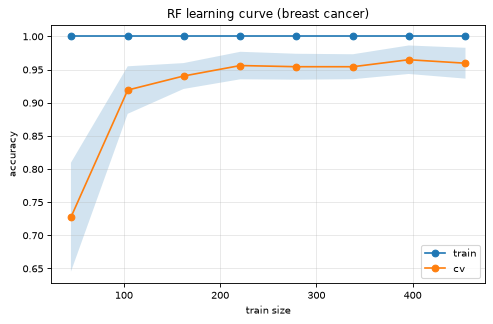

In [ ]:
SEED = 1203
X, y = load_breast_cancer(return_X_y=True)
rf = RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=1)
sizes, tr, va = learning_curve(rf, X, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 8),
                               scoring="accuracy", n_jobs=1)
tr_m, va_m = tr.mean(1), va.mean(1)
fig, ax = plt.subplots()
ax.plot(sizes, tr_m, marker="o", label="train")
ax.plot(sizes, va_m, marker="o", label="cv")
ax.fill_between(sizes, va_m - va.std(1), va_m + va.std(1), alpha=0.2)
ax.set_xlabel("train size"); ax.set_ylabel("accuracy")
ax.legend(); ax.set_title("RF learning curve (breast cancer)")
print(f"train acc at full size: {tr_m[-1]:.4f} | cv acc: {va_m[-1]:.4f}")
print(f"gap: {tr_m[-1] - va_m[-1]:.4f}")


## Notes

- Small gap, both curves flat at the end: the model is fine, the dataset is just small and easy.
- More data wouldn't move the needle much here.